# Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

# Setup

In [2]:
# Set root directory for project
current_file_dir = os.getcwd() # Get current directory
ROOT_DIR = os.path.dirname(current_file_dir) # Get project root

In [3]:
seed = 42
np.random.seed(seed)

# Helper Functions

In [4]:
def show_and_save_md(df: pd.DataFrame, name: str):
    """
    Cleans mileage strings and converts km/kg to kmpl.
    
    Args:
        df (pd.DataFrame): The dataframe to be used
        name (string): The name of the md file
    """
    df_md = df.to_markdown() # Convert to markdown

    with open(f"{ROOT_DIR}/reports/{name}.md", "w", encoding="utf-8") as f:
        f.write(df_md) # Save markdown file to reports

    print(df_md) # Show markdown table

# Ingestion

In [5]:
df = pd.read_csv(f'{ROOT_DIR}/data_raw/diabetes.csv') # Load in data

In [6]:
df.shape # Check shape of data

(768, 9)

In [7]:
df.head() # Show first few rows of data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Processing

In [8]:
df.isna().sum() # Check for missing values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"] # Set cols
df[cols] = df[cols].replace(0, np.nan) # Replace 0s with NaN for specified columns

In [10]:
df.isna().mean() # Check for missing values

Pregnancies                 0.000000
Glucose                     0.006510
BloodPressure               0.045573
SkinThickness               0.295573
Insulin                     0.486979
BMI                         0.014323
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

***Justification***

A small number of data points were found to be zero in places that should not have a 0 value. They will be removed.

In [11]:
df = df.dropna() # Remove any remaining rows with missing values

In [12]:
df.isna().sum() # Check for missing values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Amalysis

In [13]:
df_sample = df.sample(n=25, random_state=seed) # Sample 25 rows from data

## Glucose levels comparison

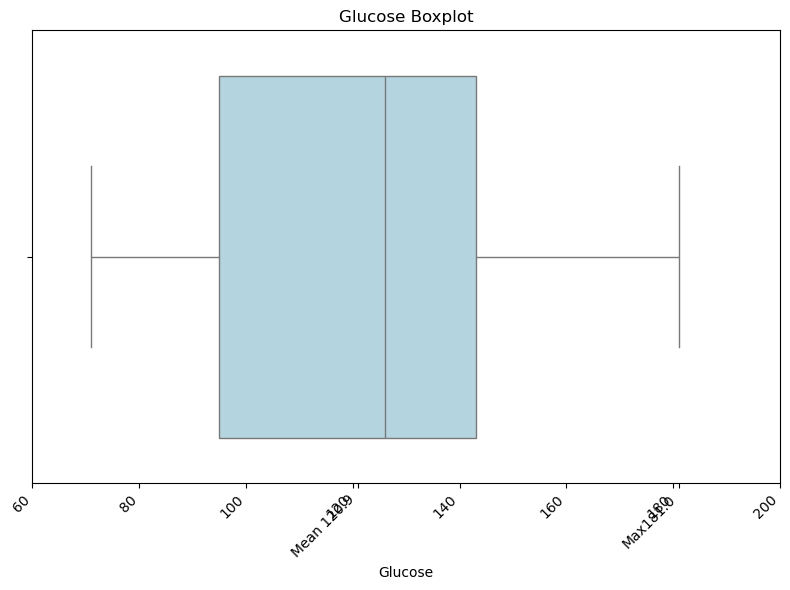

In [14]:
mean_val = df_sample['Glucose'].mean() # Get mean
max_val = df_sample['Glucose'].max() # Get max

figure, p = plt.subplots(figsize=(8, 6)) # Create figure and axis

p = sns.boxplot(x=df_sample['Glucose'], color='lightblue') # Boxplot of Glucose

# Add ticks for mean and max values
current_ticks = list(p.get_xticks())
new_ticks = sorted(current_ticks + [mean_val, max_val])
p.set_xticks(new_ticks)
labels = []
for tick in new_ticks:
    if tick == mean_val:
        labels.append(f"Mean {tick:.1f}")
    elif tick == max_val:
        labels.append(f"Max{tick:.1f}")
    else:
        labels.append(f"{tick:.0f}")
p.set_xticklabels(labels, rotation=45, ha='right')

p.set_title('Glucose Boxplot')
plt.tight_layout()
plt.savefig(f'{ROOT_DIR}/reports/glucose_boxplot.png')
plt.show()

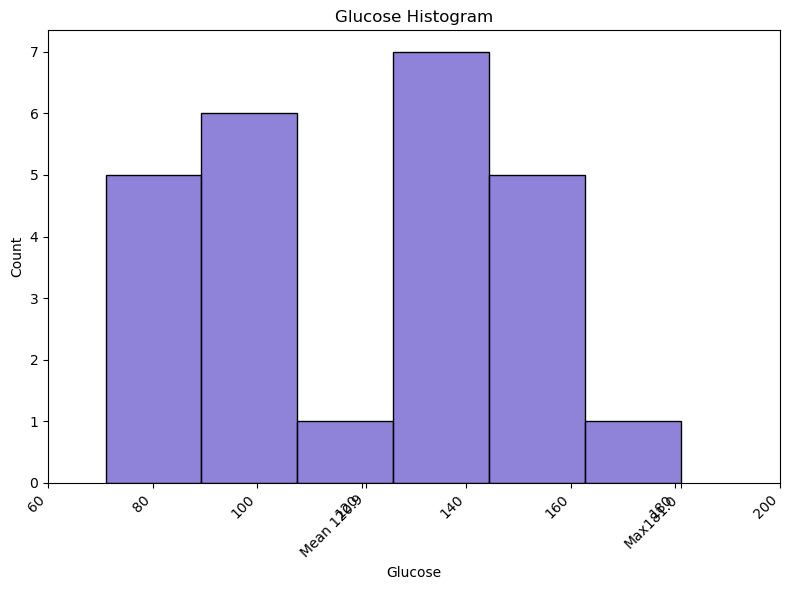

In [15]:
mean_val = df_sample['Glucose'].mean() # Get mean
max_val = df_sample['Glucose'].max() # Get max

figure, p = plt.subplots(figsize=(8, 6)) # Create figure and axis

p = sns.histplot(x=df_sample['Glucose'], color='slateblue') # Histogram of Glucose

# Add ticks for mean and max values
current_ticks = list(p.get_xticks())
new_ticks = sorted(current_ticks + [mean_val, max_val])
p.set_xticks(new_ticks)
labels = []
for tick in new_ticks:
    if tick == mean_val:
        labels.append(f"Mean {tick:.1f}")
    elif tick == max_val:
        labels.append(f"Max{tick:.1f}")
    else:
        labels.append(f"{tick:.0f}")
p.set_xticklabels(labels, rotation=45, ha='right')

p.set_title('Glucose Histogram')
plt.tight_layout()
plt.savefig(f'{ROOT_DIR}/reports/glucose_histogram.png')
plt.show()

***Comparison***

The glucose levels distribution is right scewed showing that most of the sample has normal glucose readings. There are fewer people that have higher glucose readings.

## BMI Sample Vs Population Comparison

In [16]:
percentile_BMI_sample = df_sample["BMI"].quantile([0.98]) # Get 98th percentile of BMI from sample
percentile_BMI_population = df["BMI"].quantile([0.98]) # Get 98th percentile of BMI from population

percentile_BMI_text = f"""98th Percentile of BMI in Sample: {percentile_BMI_sample.values[0]:.2f}
98th Percentile of BMI in Population: {percentile_BMI_population.values[0]:.2f}"""

with open(f"{ROOT_DIR}/reports/98th_percentile_BMI.txt", "w") as f: # Save to file
    f.write(percentile_BMI_text)
    
print(percentile_BMI_text)

98th Percentile of BMI in Sample: 49.07
98th Percentile of BMI in Population: 47.00


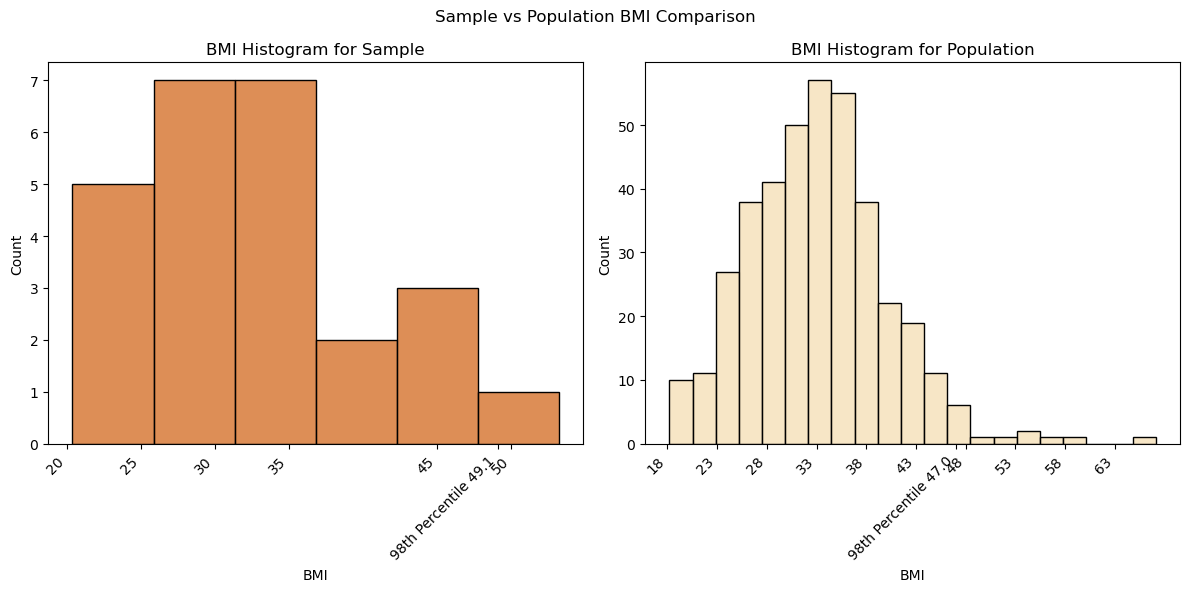

In [17]:
figure, ax = plt.subplots(1, 2, figsize=(12, 6)) # Create figure and axis
figure.suptitle('Sample vs Population BMI Comparison') # Set overall title

sns.histplot(x=df_sample['BMI'], color='chocolate', ax=ax[0]) # Histogram of BMI for sample
# Add ticks for sample
current_ticks = list(range(int(df_sample['BMI'].min()), int(df_sample['BMI'].max()), 5))
new_ticks = sorted(current_ticks + percentile_BMI_sample.values.tolist())
new_ticks = [t for t in new_ticks if abs(t - 40.0) > 1e-6] # 40 tick interfering with 98th percentile tick, so remove it
ax[0].set_xticks(new_ticks)
labels = []
for tick in new_ticks:
    if tick == percentile_BMI_sample.values[0]:
        labels.append(f"98th Percentile {tick:.1f}")
    else:
        labels.append(f"{tick:.0f}")
ax[0].set_xticklabels(labels, rotation=45, ha='right')
ax[0].set_title('BMI Histogram for Sample')

sns.histplot(x=df['BMI'], color='wheat', ax=ax[1]) # Histogram of BMI for population
# Add ticks for population
current_ticks = list(range(int(df['BMI'].min()), int(df['BMI'].max()), 5))
new_ticks = sorted(current_ticks + percentile_BMI_population.values.tolist())
ax[1].set_xticks(new_ticks)
labels = []
for tick in new_ticks:
    if tick == percentile_BMI_population.values[0]:
        labels.append(f"98th Percentile {tick:.1f}")
    else:
        labels.append(f"{tick:.0f}")
ax[1].set_xticklabels(labels, rotation=45, ha='right')
ax[1].set_title('BMI Histogram for Population')

plt.tight_layout()
plt.savefig(f'{ROOT_DIR}/reports/sample_vs_population_bmi_comparison.png')
plt.show()

***Comparison***

The BMI 98th percentile is somewhat close in sample and population. The distribution of BMI in both sample and population are similar excluding some outliers. The sample is a close representation of the population.

## Bootstraping

In [18]:
n_boots = 500
sample_size = 150

bootstrap_samples = []

for _ in range(n_boots):
    bootstrap_sample = df.sample(n=sample_size, replace=True)
    bootstrap_samples.append(bootstrap_sample)

In [19]:
bootstrap_means = [sample["BloodPressure"].mean() for sample in bootstrap_samples] # Get mean of all bootstrap sample
avg_bootstrap_mean = float(np.mean(bootstrap_means)) # Get mean of bootstrap means
bootstrap_standard_deviation = [np.std(sample["BloodPressure"], ddof=1) for sample in bootstrap_samples] # Get standard deviation of bootstrap means
avg_bootstrap_standard_deviation = float(np.mean(bootstrap_standard_deviation)) # Get mean of bootstrap standard deviations
bootstrap_percentiles = [np.percentile(sample["BloodPressure"], 98) for sample in bootstrap_samples]# Get 98th percentile of bootstrap means
avg_bootstrap_percentile = float(np.mean(bootstrap_percentiles)) # Get mean of bootstrap percentiles

In [20]:
population_mean = df["BloodPressure"].mean() # Get population mean
population_standard_deviation = df["BloodPressure"].std(ddof=1) # Get population standard deviation
population_percentile = df["BloodPressure"].quantile(0.98) # Get 98th percentile of population

In [21]:
# Create dataframe comparing population and bootstrap statistics
population_vs_bootstrap_df = pd.DataFrame({
    "Population": [population_mean, population_standard_deviation, population_percentile],
    "Bootstrap": [avg_bootstrap_mean, avg_bootstrap_standard_deviation, avg_bootstrap_percentile]
}, index=["Mean", "Standard Deviation", "98th Percentile"])

show_and_save_md(population_vs_bootstrap_df, "population_vs_bootstrap_comparison")

|                    |   Population |   Bootstrap |
|:-------------------|-------------:|------------:|
| Mean               |      70.6633 |     70.7065 |
| Standard Deviation |      12.4961 |     12.4514 |
| 98th Percentile    |      94.72   |     95.0337 |


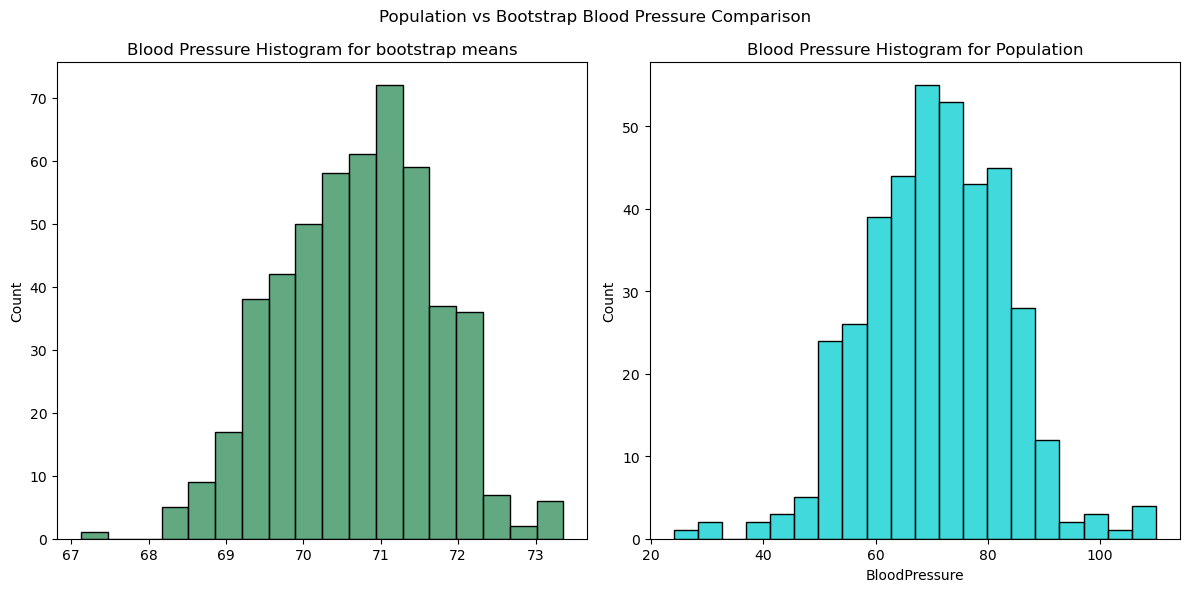

In [22]:
figure, ax = plt.subplots(1, 2, figsize=(12, 6)) # Create figure and axis
figure.suptitle('Population vs Bootstrap Blood Pressure Comparison') # Set overall title

sns.histplot(x=bootstrap_means, color='seagreen', ax=ax[0]) # Histogram of blood pressure for sample
ax[0].set_title('Blood Pressure Histogram for bootstrap means')

sns.histplot(x=df['BloodPressure'], color='darkturquoise', ax=ax[1]) # Histogram of blood pressure for population
ax[1].set_title('Blood Pressure Histogram for Population')

plt.tight_layout()
plt.savefig(f'{ROOT_DIR}/reports/population_vs_bootstrap_blood_pressure_comparison.png')
plt.show()

***Comparison***

According to the table and plots the bootstrap data is a very close match to the population data. Bootstrapping provided a much closer representation of the population than the single random sample.

# Save Clean Data

In [23]:
df.to_csv(f"{ROOT_DIR}/data_clean/diabetes_clean.csv", index=False) # Save cleaned & processed df